# Batch Feature Extraction With Train/Test Splits

This notebook prepares the feature table for modelling. It creates subject-level train/test and cross-validation fold assignments, then runs feature extraction in a resumable way.

The important leakage rule is that the same participant must never appear in both training and test data. Since each participant can contribute both eyes-open and eyes-closed rows, splitting is done at the subject level first, then applied back to the epoch files.


## 1. Setup

This notebook keeps configuration visible and uses helper functions from `src/eeg_feature_extraction.py` for the repeated feature extraction work.


In [64]:
from importlib import reload
from pathlib import Path
import os
import sys
import time

import pandas as pd
from IPython.display import Markdown, display
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.eeg_feature_extraction as efe
from src import metadata_utils

reload(efe)
reload(metadata_utils)

processed_eeg_dir = project_root / "data" / "processed" / "eeg"
metadata_path = project_root / "data" / "participant_metadata" / "participants.tsv"
feature_dir = project_root / "data" / "features"
feature_dir.mkdir(parents=True, exist_ok=True)

split_path = feature_dir / "rest_eeg_subject_splits.tsv"
train_features_path = feature_dir / "rest_eeg_features_train.tsv"
test_features_path = feature_dir / "rest_eeg_features_test.tsv"
all_features_path = feature_dir / "rest_eeg_features_split.tsv"
microstate_dir = feature_dir / "microstates"
microstate_dir.mkdir(parents=True, exist_ok=True)
microstate_features_path = microstate_dir / "rest_eeg_microstate_features.tsv"

RANDOM_STATE = 7
TEST_SIZE = 0.20
N_CV_FOLDS = 3
SPLIT_STRATIFY_COL = "APOE_group"
RUN_ALL_FEATURES = False
RUN_MICROSTATES = True
MICROSTATE_CONDITIONS = ("eyes_closed", "eyes_open")

print(f"Processed EEG dir: {processed_eeg_dir}")
print(f"Feature dir: {feature_dir}")
print(f"Microstate dir: {microstate_dir}")


Processed EEG dir: /Users/nataliemarryatt/neurogenetics-ml/data/processed/eeg
Feature dir: /Users/nataliemarryatt/neurogenetics-ml/data/features
Microstate dir: /Users/nataliemarryatt/neurogenetics-ml/data/features/microstates


## 2. Feature Settings

These settings match the feature extraction notebook. They are kept here because they define the actual feature space used for modelling.


In [54]:
EEG_BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma_low": (30.0, 40.0),
}

CONNECTIVITY_BANDS = {
    "theta": EEG_BANDS["theta"],
    "alpha": EEG_BANDS["alpha"],
    "beta": EEG_BANDS["beta"],
    "gamma_low": EEG_BANDS["gamma_low"],
}

REGION_PREFIXES = {
    "frontal": ("Fp", "AF", "AFF", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "F9", "F10", "Fz", "FFC", "FFT"),
    "central": ("FC", "FCC", "C1", "C2", "C3", "C4", "C5", "C6", "Cz", "CCP"),
    "temporal": ("FT", "FTT", "T7", "T8", "TTP", "TP", "TPP"),
    "parietal": ("CP", "CPP", "P1", "P2", "P3", "P4", "P5", "P6", "P7", "P8", "P9", "P10", "Pz", "PPO"),
    "occipital": ("PO", "POO", "O", "OI"),
}

epoch_index_preview = efe.find_clean_epoch_files(processed_eeg_dir)
if epoch_index_preview.empty:
    raise RuntimeError("No cleaned epoch files found. Finish preprocessing before running feature extraction.")

example_epochs = efe.load_epochs(epoch_index_preview.iloc[0]["path"])
all_channels = sorted({
    ch
    for path in epoch_index_preview["path"]
    for ch in efe.load_epochs(path).copy().pick("eeg", exclude=[]).ch_names
})

REGIONS = efe.make_regions_from_prefixes(all_channels, REGION_PREFIXES)

efe.EEG_BANDS = EEG_BANDS
efe.CONNECTIVITY_BANDS = CONNECTIVITY_BANDS
efe.REGIONS = REGIONS

display(efe.feature_family_table())
display(efe.region_channel_table(example_epochs))


,family,what_it_summarises,main_metrics,interpretation
0,Spectral power,How EEG power is distributed across frequency ...,"absolute power, relative power, regional power...",Higher values mean stronger activity in that b...
1,Aperiodic / 1/f,The broadband background shape of the power sp...,"aperiodic offset, aperiodic exponent, oscillat...",The exponent reflects spectral slope; peak met...
2,Time-domain,Basic properties of the cleaned EEG waveform.,"standard deviation, peak-to-peak amplitude, li...",Useful signal summaries and QC-adjacent featur...
3,Connectivity,Synchronisation between EEG channels within ea...,"mean wPLI, standard deviation of wPLI",wPLI reduces zero-lag volume-conduction effect...
4,Graph theory,Network organisation after thresholding the co...,"density, degree, strength, clustering, path le...",These compress pairwise connectivity into netw...
5,Complexity,Irregularity and fractal structure of the rest...,"permutation entropy, spectral entropy, Higuchi...",Higher entropy generally means less predictabl...
6,Microstates,"Short-lived, recurring scalp topographies and ...","duration, occurrence, coverage, transition pro...","Fit templates on training subjects only, then ..."


,region,n_channels,channels
0,frontal,32,"AF3, AF4, AF7, AF8, AFF1h, AFF2h, AFF5h, AFF6h..."
1,central,25,"C1, C2, C3, C4, C5, C6, CCP1h, CCP2h, CCP3h, C..."
2,temporal,19,"FT10, FT7, FT8, FT9, FTT10h, FTT7h, FTT8h, FTT..."
3,parietal,28,"CP1, CP2, CP3, CP4, CP5, CP6, CPP1h, CPP2h, CP..."
4,occipital,18,"O1, O10, O2, O9, OI1h, OI2h, Oz, PO10, PO3, PO..."
5,unassigned,0,


## 3. Find Clean Epoch Files

Each row is one cleaned subject-condition file. Feature extraction produces one feature row per subject and condition.


In [55]:
epoch_index = efe.find_clean_epoch_files(processed_eeg_dir)
print(f"Found {len(epoch_index)} cleaned epoch files across {epoch_index['subject_id'].nunique()} subjects.")
display(epoch_index.head())

condition_counts = epoch_index.groupby("subject_id")["condition"].nunique().value_counts().sort_index()
display(condition_counts.to_frame("n_subjects"))


Found 156 cleaned epoch files across 78 subjects.


,subject_id,condition,path
0,sub-01,eyes_closed,/Users/nataliemarryatt/neurogenetics-ml/data/p...
1,sub-01,eyes_open,/Users/nataliemarryatt/neurogenetics-ml/data/p...
2,sub-02,eyes_closed,/Users/nataliemarryatt/neurogenetics-ml/data/p...
3,sub-02,eyes_open,/Users/nataliemarryatt/neurogenetics-ml/data/p...
4,sub-03,eyes_closed,/Users/nataliemarryatt/neurogenetics-ml/data/p...


,n_subjects
condition,
2,78


## 4. Create Subject-Level Train/Test And CV Splits

The split is created at the participant level to avoid leakage between eyes-open and eyes-closed rows from the same person. The held-out test set should stay untouched until final model evaluation.

Three CV folds are used by default inside the training set. Five-fold CV is not usually too expensive once features are already extracted, but three folds is a pragmatic starting point while the pipeline is still being developed.


In [56]:
full_cohort, participants = metadata_utils.prepare_imaging_metadata(metadata_path)
participants = participants.loc[participants["participant_id"].isin(epoch_index["subject_id"])].copy()

split_subjects = (
    epoch_index[["subject_id"]]
    .drop_duplicates()
    .merge(participants, left_on="subject_id", right_on="participant_id", how="left")
)

if split_subjects[SPLIT_STRATIFY_COL].isna().any():
    missing = split_subjects.loc[split_subjects[SPLIT_STRATIFY_COL].isna(), "subject_id"].tolist()
    raise RuntimeError(f"Missing stratification labels for: {missing}")

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

subject_array = split_subjects["subject_id"].to_numpy()
y = split_subjects[SPLIT_STRATIFY_COL].to_numpy()
train_idx, test_idx = next(splitter.split(subject_array, y))

split_subjects["split"] = ""
split_subjects.loc[train_idx, "split"] = "train"
split_subjects.loc[test_idx, "split"] = "test"
split_subjects["cv_fold"] = pd.NA

train_subjects = split_subjects.loc[split_subjects["split"] == "train"].copy()
min_class_count = train_subjects[SPLIT_STRATIFY_COL].value_counts().min()
n_folds = min(N_CV_FOLDS, int(min_class_count))
if n_folds < 2:
    raise RuntimeError("Not enough subjects per class to create cross-validation folds.")

cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
for fold, (_, val_idx) in enumerate(cv.split(train_subjects["subject_id"], train_subjects[SPLIT_STRATIFY_COL]), start=1):
    val_subjects = train_subjects.iloc[val_idx]["subject_id"]
    split_subjects.loc[split_subjects["subject_id"].isin(val_subjects), "cv_fold"] = fold

split_subjects.to_csv(split_path, sep="	", index=False)

print(f"Saved subject splits to: {split_path}")
display(pd.crosstab(split_subjects["split"], split_subjects[SPLIT_STRATIFY_COL]))
display(pd.crosstab(split_subjects["cv_fold"], split_subjects[SPLIT_STRATIFY_COL], dropna=False))


Saved subject splits to: /Users/nataliemarryatt/neurogenetics-ml/data/features/rest_eeg_subject_splits.tsv


APOE_group,e4_carrier,non_e4
split,,
test,10,6
train,37,25


APOE_group,e4_carrier,non_e4
cv_fold,,
1.0,12,9
2.0,13,8
3.0,12,8
NaN,10,6


## 5. Apply Splits To Epoch Files

This table shows which cleaned epoch files belong to the training set and which belong to the held-out test set.


In [57]:
epoch_index_split = epoch_index.merge(
    split_subjects[["subject_id", "split", "cv_fold", SPLIT_STRATIFY_COL]],
    on="subject_id",
    how="inner",
)

print(epoch_index_split["split"].value_counts().to_string())
display(epoch_index_split.head())

train_subject_ids = set(split_subjects.loc[split_subjects["split"] == "train", "subject_id"])
test_subject_ids = set(split_subjects.loc[split_subjects["split"] == "test", "subject_id"])


split
train    124
test      32


,subject_id,condition,path,split,cv_fold,APOE_group
0,sub-01,eyes_closed,/Users/nataliemarryatt/neurogenetics-ml/data/p...,train,1,non_e4
1,sub-01,eyes_open,/Users/nataliemarryatt/neurogenetics-ml/data/p...,train,1,non_e4
2,sub-02,eyes_closed,/Users/nataliemarryatt/neurogenetics-ml/data/p...,train,1,non_e4
3,sub-02,eyes_open,/Users/nataliemarryatt/neurogenetics-ml/data/p...,train,1,non_e4
4,sub-03,eyes_closed,/Users/nataliemarryatt/neurogenetics-ml/data/p...,train,2,non_e4


## 6. Time One Feature Row

This estimates how long a full run may take on this laptop. Connectivity and graph metrics are usually the slowest part.


In [58]:
test_row = epoch_index_split.iloc[0]
start = time.time()
_ = efe.extract_epoch_file_features(test_row)
elapsed = time.time() - start
estimated_minutes = elapsed * len(epoch_index_split) / 60

print(f"One subject-condition file took {elapsed:.1f} seconds")
print(f"Estimated full extraction time: {estimated_minutes:.1f} minutes for {len(epoch_index_split)} files")


One subject-condition file took 11.4 seconds
Estimated full extraction time: 29.5 minutes for 156 files


## 7. Extract Training Features First

This creates the training feature table first. Progress is saved after every subject-condition row, so rerunning the cell with `RUN_ALL_FEATURES = False` resumes rather than starting again.


In [59]:
train_features = efe.extract_features_resumable(
    epoch_index_split,
    train_features_path,
    subject_ids=train_subject_ids,
    run_all=RUN_ALL_FEATURES,
)

print(train_features.shape)
display(train_features.head())


Skipping existing sub-01 eyes_closed
Skipping existing sub-01 eyes_open
Skipping existing sub-02 eyes_closed
Skipping existing sub-02 eyes_open
Skipping existing sub-03 eyes_closed
Skipping existing sub-03 eyes_open
Skipping existing sub-04 eyes_closed
Skipping existing sub-04 eyes_open
Skipping existing sub-05 eyes_closed
Skipping existing sub-05 eyes_open
Skipping existing sub-06 eyes_closed
Skipping existing sub-06 eyes_open
Skipping existing sub-07 eyes_closed
Skipping existing sub-07 eyes_open
Skipping existing sub-09 eyes_closed
Skipping existing sub-09 eyes_open
Skipping existing sub-12 eyes_closed
Skipping existing sub-12 eyes_open
Skipping existing sub-13 eyes_closed
Skipping existing sub-13 eyes_open
Skipping existing sub-14 eyes_closed
Skipping existing sub-14 eyes_open
Skipping existing sub-15 eyes_closed
Skipping existing sub-15 eyes_open
Skipping existing sub-16 eyes_closed
Skipping existing sub-16 eyes_open
Skipping existing sub-17 eyes_closed
Skipping existing sub-17 ey

,subject_id,condition,n_epochs,n_channels,sfreq,power_abs_delta_global,power_rel_delta_global,power_abs_delta_frontal,power_rel_delta_frontal,power_abs_delta_central,...,graph_wpli_gamma_low_strength_mean,graph_wpli_gamma_low_strength_sd,graph_wpli_gamma_low_clustering_mean,graph_wpli_gamma_low_path_length,graph_wpli_gamma_low_global_efficiency,graph_wpli_gamma_low_local_efficiency,graph_wpli_gamma_low_path_length_binary,graph_wpli_gamma_low_random_clustering_mean,graph_wpli_gamma_low_random_path_length_mean,graph_wpli_gamma_low_small_world_sigma
0,sub-01,eyes_closed,179,122,250.0,5.728358e-12,0.186839,6.241566e-12,0.213631,4.650193e-12,...,5.443615,3.113692,0.409056,9.051994,0.123630,0.137250,1.792305,0.251150,1.750373,1.590630
1,sub-01,eyes_open,119,124,250.0,4.624247e-12,0.218260,5.042185e-12,0.211379,4.528337e-12,...,6.242515,3.301783,0.352077,8.019400,0.138617,0.145512,1.780357,0.249705,1.750170,1.386063
2,sub-02,eyes_closed,179,126,250.0,1.377732e-12,0.177389,1.688758e-12,0.186540,1.040198e-12,...,9.192692,5.931517,0.421992,5.559772,0.199653,0.239779,1.794839,0.251061,1.750133,1.638968
3,sub-02,eyes_open,118,125,250.0,1.356248e-12,0.208991,1.842472e-12,0.242916,1.163908e-12,...,8.347293,4.495121,0.362544,6.102047,0.183014,0.202345,1.802839,0.251239,1.750219,1.400910
4,sub-03,eyes_closed,180,126,250.0,2.648048e-12,0.190660,3.299501e-12,0.232793,2.149753e-12,...,5.741539,3.493650,0.398343,9.033808,0.122779,0.137352,1.789968,0.251061,1.750133,1.551328


## 8. Extract Held-Out Test Features

These features are extracted with the same fixed settings. Do not use the held-out test labels for model selection or feature selection later.


In [60]:
test_features = efe.extract_features_resumable(
    epoch_index_split,
    test_features_path,
    subject_ids=test_subject_ids,
    run_all=RUN_ALL_FEATURES,
)

print(test_features.shape)
display(test_features.head())


Skipping existing sub-08 eyes_closed
Skipping existing sub-08 eyes_open
Skipping existing sub-10 eyes_closed
Skipping existing sub-10 eyes_open
Skipping existing sub-11 eyes_closed
Skipping existing sub-11 eyes_open
Skipping existing sub-24 eyes_closed
Skipping existing sub-24 eyes_open
Skipping existing sub-29 eyes_closed
Skipping existing sub-29 eyes_open
Skipping existing sub-31 eyes_closed
Skipping existing sub-31 eyes_open
Skipping existing sub-35 eyes_closed
Skipping existing sub-35 eyes_open
Skipping existing sub-36 eyes_closed
Skipping existing sub-36 eyes_open
Skipping existing sub-40 eyes_closed
Skipping existing sub-40 eyes_open
Skipping existing sub-46 eyes_closed
Skipping existing sub-46 eyes_open
Skipping existing sub-51 eyes_closed
Skipping existing sub-51 eyes_open
Skipping existing sub-56 eyes_closed
Skipping existing sub-56 eyes_open
Skipping existing sub-58 eyes_closed
Skipping existing sub-58 eyes_open
Skipping existing sub-61 eyes_closed
Skipping existing sub-61 ey

,subject_id,condition,n_epochs,n_channels,sfreq,power_abs_delta_global,power_rel_delta_global,power_abs_delta_frontal,power_rel_delta_frontal,power_abs_delta_central,...,graph_wpli_gamma_low_strength_mean,graph_wpli_gamma_low_strength_sd,graph_wpli_gamma_low_clustering_mean,graph_wpli_gamma_low_path_length,graph_wpli_gamma_low_global_efficiency,graph_wpli_gamma_low_local_efficiency,graph_wpli_gamma_low_path_length_binary,graph_wpli_gamma_low_random_clustering_mean,graph_wpli_gamma_low_random_path_length_mean,graph_wpli_gamma_low_small_world_sigma
0,sub-08,eyes_closed,180,120,250.0,2.509083e-12,0.225819,3.055633e-12,0.289903,2.313580e-12,...,7.692201,4.738154,0.401343,6.342284,0.174394,0.197580,1.808683,0.249185,1.750336,1.558664
1,sub-08,eyes_open,120,120,250.0,3.058008e-12,0.255275,3.580844e-12,0.312511,3.178587e-12,...,6.794598,4.888983,0.476900,7.541837,0.152313,0.195936,1.805742,0.249185,1.750336,1.855117
2,sub-09,eyes_closed,180,127,250.0,2.430272e-12,0.237317,3.563157e-12,0.289365,1.637527e-12,...,9.261011,8.550357,0.525642,6.074735,0.197092,0.310615,1.837460,0.250951,1.750106,1.995021
3,sub-09,eyes_open,119,125,250.0,2.985403e-12,0.284964,4.074372e-12,0.337593,2.074454e-12,...,15.515366,11.490763,0.506312,3.313640,0.335613,0.464212,1.784815,0.251239,1.750219,1.976200
4,sub-10,eyes_closed,180,125,250.0,2.899417e-12,0.141641,3.657954e-12,0.177263,2.232273e-12,...,4.917593,2.803949,0.374761,9.445561,0.116271,0.124742,1.776129,0.251239,1.750219,1.469894


## 9. Add Training-Derived Microstate Features

Microstate features are handled after the subject-level split because the templates are learned from data. To avoid leakage into the final held-out test set, templates are fitted using training subjects only. The fitted templates are then backfitted to both training and test subjects so the resulting microstate features are comparable.

By default, `MICROSTATE_CONDITIONS = ("eyes_closed",)`, so only eyes-closed rows receive microstate features. This is why microstate columns will be missing for eyes-open rows in the combined table. To run both resting conditions, set `MICROSTATE_CONDITIONS = ("eyes_closed", "eyes_open")`, but expect roughly double the runtime.


/Users/nataliemarryatt/neurogenetics-ml/src/eeg_feature_extraction.py:983: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  show=False,


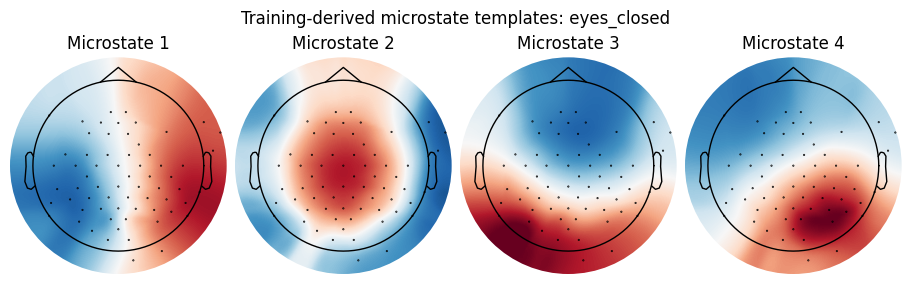

/Users/nataliemarryatt/neurogenetics-ml/src/eeg_feature_extraction.py:983: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  show=False,


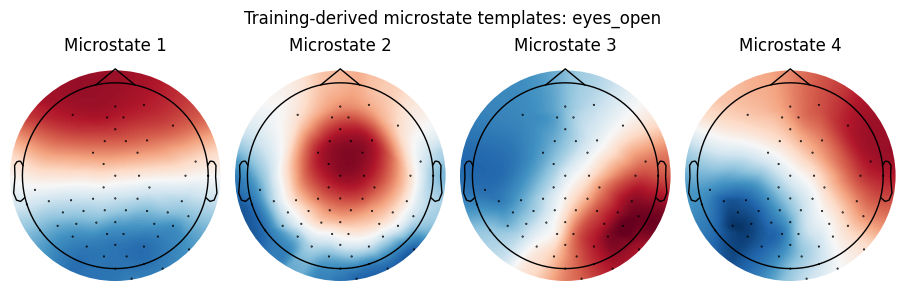

Backfitting microstates sub-01 eyes_closed
Backfitting microstates sub-02 eyes_closed
Backfitting microstates sub-03 eyes_closed
Backfitting microstates sub-04 eyes_closed
Backfitting microstates sub-05 eyes_closed
Backfitting microstates sub-06 eyes_closed
Backfitting microstates sub-07 eyes_closed
Backfitting microstates sub-08 eyes_closed
Backfitting microstates sub-09 eyes_closed
Backfitting microstates sub-10 eyes_closed
Backfitting microstates sub-11 eyes_closed
Backfitting microstates sub-12 eyes_closed
Backfitting microstates sub-13 eyes_closed
Backfitting microstates sub-14 eyes_closed
Backfitting microstates sub-15 eyes_closed
Backfitting microstates sub-16 eyes_closed
Backfitting microstates sub-17 eyes_closed
Backfitting microstates sub-18 eyes_closed
Backfitting microstates sub-19 eyes_closed
Backfitting microstates sub-20 eyes_closed
Backfitting microstates sub-21 eyes_closed
Backfitting microstates sub-22 eyes_closed
Backfitting microstates sub-23 eyes_closed
Backfitting

,condition,n_training_subjects,n_epoch_files,max_epochs_per_subject,n_epochs_total,n_common_channels,n_gfp_peaks,n_microstates,n_init,gfp_peak_seconds,template_fit_seconds,total_fit_seconds,total_fit_minutes,global_explained_variance,template_figure_path
eyes_closed,eyes_closed,62,62,30,1860,65,133631,4,10,101.387612,26.416072,127.803684,2.130061,0.560913,/Users/nataliemarryatt/neurogenetics-ml/data/f...
eyes_open,eyes_open,62,62,30,1860,56,147144,4,10,86.599776,23.335123,109.934899,1.832248,0.537588,/Users/nataliemarryatt/neurogenetics-ml/data/f...


,subject_id,condition,microstate_0_mean_corr,microstate_0_gev,microstate_0_occurrences,microstate_0_timecov,microstate_0_meandurs,microstate_1_mean_corr,microstate_1_gev,microstate_1_occurrences,...,microstate_2_gev,microstate_2_occurrences,microstate_2_timecov,microstate_2_meandurs,microstate_3_mean_corr,microstate_3_gev,microstate_3_occurrences,microstate_3_timecov,microstate_3_meandurs,microstate_unlabeled
0,sub-01,eyes_closed,0.653238,0.125771,17.253497,0.255538,0.014811,0.658532,0.140959,16.870905,...,0.208167,18.171719,0.315211,0.017346,0.604612,0.053143,12.781418,0.149659,0.011709,0.014369
1,sub-01,eyes_open,0.690366,0.170719,18.795039,0.254877,0.013561,0.616934,0.118431,17.355492,...,0.096566,18.062488,0.223377,0.012367,0.645947,0.137171,19.025026,0.261299,0.013734,0.013462
2,sub-02,eyes_closed,0.639089,0.146566,22.286997,0.287698,0.012909,0.588493,0.074935,18.586162,...,0.102153,19.688779,0.216565,0.010999,0.654798,0.163507,22.213489,0.291656,0.013130,0.012000
3,sub-02,eyes_open,0.678007,0.178689,24.972158,0.274480,0.010991,0.593613,0.105214,21.960935,...,0.111701,25.426197,0.254433,0.010007,0.601124,0.089712,23.545789,0.223062,0.009474,0.010763
4,sub-03,eyes_closed,0.589114,0.057490,13.885131,0.160027,0.011525,0.668548,0.219424,19.611656,...,0.119752,16.765303,0.227821,0.013589,0.633334,0.110786,17.481118,0.245305,0.014033,0.014333


In [65]:
if RUN_MICROSTATES:
    # Fit separate training-derived templates for each selected condition.
    microstate_result = efe.fit_microstate_templates_by_condition(
        epoch_index_split,
        train_subject_ids,
        microstate_dir,
        channel_subject_ids=train_subject_ids | test_subject_ids,
        conditions=MICROSTATE_CONDITIONS,
        n_clusters=4,
        n_init=10,
        random_state=RANDOM_STATE,
        max_epochs_per_subject=30,
    )

    # Backfit the training-derived templates to all subjects for matching conditions.
    microstate_features = efe.backfit_microstate_features_by_condition(
        epoch_index_split,
        microstate_result["models"],
        microstate_features_path,
        subject_ids=train_subject_ids | test_subject_ids,
        run_all=True,
    )

    display(microstate_result["summary"])
    display(microstate_features.head())
else:
    print("Microstate extraction skipped. Set RUN_MICROSTATES = True to fit training-derived templates and backfit features.")


## 10. Combine Features With Split Labels

The combined table is convenient for later modelling notebooks, but model code should still respect the `split`, `cv_fold`, and `subject_id` columns.


In [66]:
features = pd.concat([train_features, test_features], ignore_index=True)
features = features.drop_duplicates(["subject_id", "condition"], keep="last")

if microstate_features_path.exists():
    microstate_features = pd.read_csv(microstate_features_path, sep="\t")
    microstate_features = microstate_features.drop_duplicates(["subject_id", "condition"], keep="last")
    features = features.merge(
        microstate_features,
        on=["subject_id", "condition"],
        how="left",
        suffixes=("", "_microstate"),
    )

features = features.merge(
    split_subjects[["subject_id", "split", "cv_fold", "APOE_group", "PICALM_group", "APOE_risk_dosage", "PICALM_risk_dosage", "age", "sex", "education"]],
    on="subject_id",
    how="left",
)
features = features.sort_values(["split", "subject_id", "condition"]).reset_index(drop=True)
features.to_csv(all_features_path, sep="\t", index=False)

print(f"Saved combined split feature table to: {all_features_path}")
print(features.shape)
display(features[["subject_id", "condition", "split", "cv_fold", "APOE_group", "PICALM_group"]].head(20))


Saved combined split feature table to: /Users/nataliemarryatt/neurogenetics-ml/data/features/rest_eeg_features_split.tsv
(156, 175)


,subject_id,condition,split,cv_fold,APOE_group,PICALM_group
0,sub-08,eyes_closed,test,<NA>,non_e4,AA_AG
1,sub-08,eyes_open,test,<NA>,non_e4,AA_AG
2,sub-10,eyes_closed,test,<NA>,non_e4,AA_AG
3,sub-10,eyes_open,test,<NA>,non_e4,AA_AG
4,sub-11,eyes_closed,test,<NA>,non_e4,AA_AG
5,sub-11,eyes_open,test,<NA>,non_e4,AA_AG
6,sub-24,eyes_closed,test,<NA>,non_e4,AA_AG
7,sub-24,eyes_open,test,<NA>,non_e4,AA_AG
8,sub-29,eyes_closed,test,<NA>,non_e4,AA_AG
9,sub-29,eyes_open,test,<NA>,non_e4,AA_AG


## 11. Checks Before Modelling

These checks make sure the split is subject-clean and that no participant appears in both train and test.


In [67]:
train_ids = set(features.loc[features["split"] == "train", "subject_id"])
test_ids = set(features.loc[features["split"] == "test", "subject_id"])
overlap = train_ids & test_ids

print(f"Train subjects: {len(train_ids)}")
print(f"Test subjects: {len(test_ids)}")
print(f"Train/test overlap: {len(overlap)}")

if overlap:
    raise RuntimeError(f"Subject leakage detected: {sorted(overlap)}")

missing_by_col = features.isna().mean().sort_values(ascending=False)
display(missing_by_col[missing_by_col > 0].to_frame("missing_fraction").head(30))


Train subjects: 62
Test subjects: 16
Train/test overlap: 0


,missing_fraction
cv_fold,0.205128
education,0.102564


## Notes For The Modelling Notebook

For the next modelling notebook, fit scalers, imputers, feature selection, and models on the training folds only. The held-out test set should be used once at the end for final evaluation.

Most current features are computed independently per subject-condition file, so they do not require train-only fitting. Microstates are the exception because the templates are learned from data. This notebook handles the final hold-out test set safely by fitting templates on training subjects only and backfitting them to held-out subjects.

For fully leakage-safe cross-validation estimates involving microstate features, the strictest approach is to fit separate microstate templates inside each training fold and backfit them to that fold's validation subjects. That is more computationally expensive, so this notebook keeps the first implementation focused on the final train/test workflow.
